# RQ3: Heatwaves in European Major Cities (1980-2025)

**LLM note:** the merge of this
notebook's two sources (`RQ3.ipynb` for data collection, `RQ3 FINAL.ipynb`
for the cleaned analysis) were done with the help of Claude (Anthropic).
The data collection, heatwave definition, and statistical analysis are the
project's own work, carried over from those notebooks (originally German).

**Research question:** How have the frequency, intensity, and duration of
heatwaves in European major cities changed between 1980 and today, and
which country is most affected?

Part 1 below collects the data; Part 2 analyzes it.



## 1. Data collection

### Step 1 - Cities and capitals

GeoNames: every city with >=500,000 inhabitants across `european_countries`,
plus each country's capital (even if smaller, e.g. Reykjavik). Cached
locally as CSV after the first run to avoid ~150 repeat requests.

In [1]:
# European major cities (>=500,000 inhabitants) + national capitals, via the GeoNames search API
import requests
import pandas as pd
import numpy as np
import time
import os

european_countries = [
    "AD", "AL", "AT", "AX", "BA", "BE", "BG", "BY",
    "CH", "CZ", "DE", "DK", "EE", "ES", "FI", "FO",
    "FR", "GB", "GG", "GI", "GR", "HR", "HU", "IE",
    "IM", "IS", "IT", "JE", "LI", "LT", "LU", "LV",
    "MC", "MD", "ME", "MK", "MT", "NL", "NO", "PL",
    "PT", "RO", "RS", "SE", "SI", "SJ", "SK",
    "SM", "UA", "VA",
]

GEONAMES_URL = "https://secure.geonames.org/searchJSON"
GEONAMES_USER = "timos98"
CITIES_CACHE_PATH = "data/raw/cities_europe.csv"  # local cache, so GeoNames isn't queried on every restart


def _place_row(place, is_capital):
    # Converts one GeoNames response into this project's row format.
    return {
        "geoname_id": place.get("geonameId"),
        "city": place.get("name"),
        "country": place.get("countryName"),
        "country_code": place.get("countryCode"),
        "population": int(place.get("population", 0) or 0),
        "lat": float(place.get("lat")),
        "lon": float(place.get("lng")),
        "is_capital": is_capital,
    }


def fetch_large_cities(country, min_population=500000, pause=1.0):
    """All cities in a country with population >= min_population."""
    rows, start_row = [], 0
    while True:
        # GeoNames returns at most 1000 results per request -> page with startRow as needed
        params = {
            "country": country, "featureClass": "P",
            "maxRows": 1000, "startRow": start_row,
            "username": GEONAMES_USER,
        }
        try:
            r = requests.get(GEONAMES_URL, params=params, timeout=30)
            r.raise_for_status()
            places = r.json().get("geonames", [])
        except Exception as e:
            print(f"  Error for {country} (population search, startRow={start_row}): {e}")
            break

        if not places:
            break  # no more pages for this country
        for place in places:
            if int(place.get("population", 0) or 0) >= min_population:
                rows.append(_place_row(place, is_capital=False))
        start_row += 1000
        time.sleep(pause)  # brief pause, so as not to overwhelm GeoNames with requests
    return rows


def fetch_capital(country, pause=1.0):
    """A country's capital: featureCode PPLC, falling back to PPLA."""
    for feature_code in ("PPLC", "PPLA"):
        params = {
            "country": country, "featureCode": feature_code,
            "maxRows": 1, "username": GEONAMES_USER,
        }
        try:
            r = requests.get(GEONAMES_URL, params=params, timeout=30)
            r.raise_for_status()
            places = r.json().get("geonames", [])
        except Exception as e:
            print(f"  Error for {country} (capital search, {feature_code}): {e}")
            places = []
        time.sleep(pause)
        if places:
            return _place_row(places[0], is_capital=True)
    print(f"  No capital found for {country} (neither PPLC nor PPLA)")
    return None


def get_european_cities(min_population=500000):
    all_rows = []
    for country in european_countries:
        all_rows.extend(fetch_large_cities(country, min_population=min_population))
        cap = fetch_capital(country)
        if cap is not None:
            all_rows.append(cap)

    df = pd.DataFrame(all_rows)
    # Merge duplicates (same geoname_id), preferring the capital-flagged row.
    df = (df.sort_values("is_capital", ascending=False)
            .drop_duplicates(subset="geoname_id", keep="first"))
    return df.sort_values("population", ascending=False).reset_index(drop=True)


# Cache lookup: if the file already exists, read it instead of re-querying GeoNames.
if os.path.exists(CITIES_CACHE_PATH):
    cities_df = pd.read_csv(CITIES_CACHE_PATH)
    print(f"cities_df loaded from cache: {CITIES_CACHE_PATH}")
else:
    cities_df = get_european_cities(min_population=500000)
    os.makedirs("data/raw", exist_ok=True)
    cities_df.to_csv(CITIES_CACHE_PATH, index=False)
    print(f"cities_df freshly loaded from GeoNames and saved: {CITIES_CACHE_PATH}")

print(f"{len(cities_df)} cities in {cities_df['country'].nunique()} countries")
print(f"...of which only included due to capital status (<500,000 pop.): "
      f"{((cities_df['is_capital']) & (cities_df['population'] < 500000)).sum()}")

cities_df loaded from cache: data/raw/cities_europe.csv
101 cities in 50 countries
...of which only included due to capital status (<500,000 pop.): 22


### Step 2 - Finding duplicates

Cities with near-identical coordinates (<0.05 degrees, ~5 km) are flagged
as candidates - e.g. Budapest's old Buda/Pest entries. Only listed here,
not auto-removed: two real neighboring cities can also be close together.

In [2]:
import itertools

close_pairs = []
# itertools.combinations forms every possible city pair exactly once (not A-B and B-A twice)
for (i1, r1), (i2, r2) in itertools.combinations(cities_df.iterrows(), 2):
    # simple Euclidean distance in degrees (not an exact km measure, but good enough for "very close")
    dist = ((r1["lat"] - r2["lat"]) ** 2 + (r1["lon"] - r2["lon"]) ** 2) ** 0.5
    if dist < 0.05:
        close_pairs.append((i1, r1["city"], i2, r2["city"], round(dist, 4)))

print("Candidates for manual review (coordinates very close together):")
for p in close_pairs:
    print(p)

Candidates for manual review (coordinates very close together):
(9, 'Budapest', 27, 'Pest', 0.0429)
(9, 'Budapest', 75, 'Buda', 0.0073)


### Step 3 - Excluding duplicates

"Pest" (index 27) and "Buda" (index 75) are confirmed duplicates of
Budapest (index 9, kept) and skipped in every analysis cell below. They
stay in `cities_df` itself, since removing them would shift the city
batching used when fetching weather data, breaking alignment with the
HTTP cache.

In [3]:
# Row indices of exact duplicates, entered here after reviewing the candidates above.
# The indices refer to row numbers in cities_df (the left-hand column when printed).
exclude_idx = {27, 75}
print(f"{len(cities_df) - len(exclude_idx)} cities after cleanup (of {len(cities_df)})")

99 cities after cleanup (of 101)


### Step 4 - Connecting to the weather API

Same caching plus 429-retry setup as RQ1, for the same reasons: it makes
the ~100-city, 45-year collection resumable and rate-limit-safe.

In [4]:
# Open-Meteo client: FlatBuffers client + persistent cache + custom retry logic (incl. 429)
import openmeteo_requests
import requests_cache
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry


def make_client():
    # Cache never expires: past weather data doesn't change.
    cache_session = requests_cache.CachedSession(
        "openmeteo_cache", expire_after=-1, allowable_codes=[200],
    )
    # Retry with growing wait times on rate limits and server errors.
    retry = Retry(
        total=6, backoff_factor=3,
        status_forcelist=[429, 500, 502, 503, 504],
        allowed_methods=["GET"],
    )
    cache_session.mount("https://", HTTPAdapter(max_retries=retry))
    cache_session.headers.update({"User-Agent": "student-project/1.0"})
    return openmeteo_requests.Client(session=cache_session)


CLIENT = make_client()

### Step 5 - Fetching temperatures and detecting heatwaves

Same five building blocks as RQ1 - batch/range fetch, per-day threshold,
heatwave detection, and a per-city wrapper.

In [5]:
# Functions: fetch weather data (openmeteo_requests) + detect heatwaves
import time

ARCHIVE_URL = "https://archive-api.open-meteo.com/v1/archive"


def fetch_tmax_batch(client, coords, start_date, end_date, batch_size=15, pause=5):
    """Fetch daily maximum temperatures for several cities at once."""
    dfs = []
    n_batches = -(-len(coords) // batch_size)  # ceiling division

    for b in range(n_batches):
        i = b * batch_size
        chunk = coords[i:i + batch_size]

        params = {
            "latitude": [lat for lat, lon in chunk],
            "longitude": [lon for lat, lon in chunk],
            "start_date": start_date, "end_date": end_date,
            "daily": ["temperature_2m_max"],
            "timezone": "Europe/Berlin",
        }
        try:
            responses = client.weather_api(ARCHIVE_URL, params=params)  # one response per city
        except Exception as e:
            raise RuntimeError(f"API error in batch {b + 1}/{n_batches}: {e}") from e

        for response in responses:
            daily = response.Daily()
            tmax = daily.Variables(0).ValuesAsNumpy()
            # Open-Meteo returns start/end/interval instead of a date list, so build it here
            dates = pd.date_range(
                start=pd.to_datetime(daily.Time(), unit="s", utc=True),
                end=pd.to_datetime(daily.TimeEnd(), unit="s", utc=True),
                freq=pd.Timedelta(seconds=daily.Interval()),
                inclusive="left",
            ).tz_localize(None)
            dfs.append(pd.DataFrame({"date": dates, "tmax": tmax}))

        print(f"  Batch {b + 1}/{n_batches} ok ({len(chunk)} cities)")
        time.sleep(pause)  # stay under the API's rate limit

    return dfs


def fetch_tmax_range(client, coords, start_date, end_date, batch_size=15, year_chunk=5, pause=5):
    """Fetch tmax over a long period, split into city and year batches."""
    start_year, end_year = int(start_date[:4]), int(end_date[:4])

    # split the overall period into blocks of `year_chunk` years each
    year_ranges = []
    y = start_year
    while y <= end_year:
        y2 = min(y + year_chunk - 1, end_year)
        year_ranges.append((f"{y}-01-01", f"{y2}-12-31"))
        y = y2 + 1

    all_parts = {i: [] for i in range(len(coords))}  # collects every year block per city (index i)
    for chunk_start, chunk_end in year_ranges:
        print(f"Period {chunk_start[:4]}-{chunk_end[:4]}:")
        dfs = fetch_tmax_batch(client, coords, chunk_start, chunk_end, batch_size=batch_size, pause=pause)
        for i, df in enumerate(dfs):
            all_parts[i].append(df)
        time.sleep(pause)  # extra buffer between time blocks

    # combine every year block per city into one continuous, time-sorted series
    return [pd.concat(all_parts[i], ignore_index=True).sort_values("date").reset_index(drop=True)
            for i in range(len(coords))]


def compute_doy_thresholds(ref_df, window=15, percentile=98):
    """Threshold per calendar day: 98th percentile within +/-15 days of the reference period."""
    doy = ref_df["doy"].to_numpy()
    tmax = ref_df["tmax"].to_numpy()
    thresholds = {}

    for d in range(1, 366):
        dist = np.abs(doy - d)
        dist = np.minimum(dist, 365 - dist)  # wrap around the turn of the year
        thresholds[d] = np.percentile(tmax[dist <= window], percentile)

    return thresholds


def find_dwd_heatwaves(df, thresholds, min_days=3, fixed_threshold=28.0):
    """A heatwave is >= 3 consecutive days above both the climate threshold and 28 degrees C."""
    df = df.copy()
    df["doy"] = df["date"].dt.dayofyear.clip(upper=365)  # leap-year day 366 folds into 365
    df["threshold"] = df["doy"].map(thresholds)
    df["is_hot"] = (df["tmax"] > df["threshold"]) & (df["tmax"] > fixed_threshold)

    # Track hot streaks: `start` marks where the current one began. if any.
    heatwaves, start = [], None
    for i, row in df.iterrows():
        if row["is_hot"] and start is None:
            start = i
        elif not row["is_hot"] and start is not None:
            segment = df.loc[start:i - 1]
            if len(segment) >= min_days:
                heatwaves.append({
                    "start": segment["date"].iloc[0].date(),
                    "end": segment["date"].iloc[-1].date(),
                    "duration_days": len(segment),
                    "max_temp": round(segment["tmax"].max(), 1),
                    "avg_temp": round(segment["tmax"].mean(), 1),
                })
            start = None

    if start is not None:  # data ends mid-heatwave
        segment = df.loc[start:]
        if len(segment) >= min_days:
            heatwaves.append({
                "start": segment["date"].iloc[0].date(),
                "end": segment["date"].iloc[-1].date(),
                "duration_days": len(segment),
                "max_temp": round(segment["tmax"].max(), 1),
                "avg_temp": round(segment["tmax"].mean(), 1),
            })

    return heatwaves


def analyze_city_heatwaves_from_data(ref_df, analysis_df):
    """Combine threshold calculation and heatwave search for a single city."""
    ref_df = ref_df.copy()
    ref_df["doy"] = ref_df["date"].dt.dayofyear.clip(upper=365)
    thresholds = compute_doy_thresholds(ref_df)
    return find_dwd_heatwaves(analysis_df, thresholds)

### Step 6 - Smoke test

A small 3-city, 1-month request confirms the pipeline works before the
full run. Commented out below to skip a live call on every execution.

In [6]:
# Smoke test: confirm the client + fetch_tmax_batch work (3 cities, one month)
# coords = list(zip(cities_df["lat"], cities_df["lon"]))
# test = fetch_tmax_batch(CLIENT, coords[:3], "2025-01-01", "2025-01-31")
# [len(df) for df in test]  # -> 3 entries, ~31 rows each

### Step 7 - Running the full collection

The code below was run once (~15-20 minutes for ~100 cities) to fetch both
periods, detect heatwaves per city (skipping the duplicates from Step 3),
and save the results. A failure in a single city (e.g. corrupt data) is
logged and skipped, not fatal to the whole run.

```python
coords = list(zip(cities_df["lat"], cities_df["lon"]))

time.sleep(5)  # give the API's rate limit a moment to recover, in case another run just finished
ref_dfs = fetch_tmax_range(CLIENT, coords, "1961-01-01", "1990-12-31", batch_size=15, year_chunk=10, pause=1)
analysis_dfs = fetch_tmax_range(CLIENT, coords, "1980-01-01", "2025-12-31", batch_size=15, year_chunk=5, pause=1)

results = []
failed_cities = []
for idx, row in cities_df.iterrows():
    if idx in exclude_idx:
        continue
    try:
        heatwaves = analyze_city_heatwaves_from_data(ref_dfs[idx], analysis_dfs[idx])
        for hw in heatwaves:
            results.append({
                "city": row["city"], "country": row["country"],
                "population": row["population"], "is_capital": row["is_capital"],
                **hw,
            })
    except Exception as e:
        print(f"  Skipped due to error ({row['city']}): {e}")
        failed_cities.append(row["city"])

results_df = pd.DataFrame(results)
results_df["year"] = pd.to_datetime(results_df["start"]).dt.year

os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)

raw_rows = [analysis_dfs[idx].assign(city=row["city"], country=row["country"])
            for idx, row in cities_df.iterrows() if idx not in exclude_idx]
pd.concat(raw_rows, ignore_index=True).to_parquet("data/raw/tmax_europe_1980_2025.parquet", index=False)

results_df.to_csv("data/processed/heatwaves_europe.csv", index=False)
```

The rest of this notebook loads that output and re-requests the reference
period straight from the (already warm) local HTTP cache - fast, since no
live request is actually needed.

In [7]:
# Load the already-collected data: detected heatwaves + raw daily temperatures
results_df = pd.read_csv("data/processed/heatwaves_europe.csv", parse_dates=["start", "end"])
tmax_df = pd.read_parquet("data/raw/tmax_europe_1980_2025.parquet")

# Reference period wasn't saved separately for Europe -- re-fetched here, served from the local cache.
coords = list(zip(cities_df["lat"], cities_df["lon"]))
ref_dfs = fetch_tmax_range(CLIENT, coords, "1961-01-01", "1990-12-31", year_chunk=10, pause=0.1)

print(f"{len(results_df)} heatwaves loaded, covering {results_df['city'].nunique()} cities "
      f"in {results_df['country'].nunique()} countries")

Period 1961-1970:

  Batch 1/7 ok (15 cities)
  Batch 2/7 ok (15 cities)


  Batch 3/7 ok (15 cities)


  Batch 4/7 ok (15 cities)


  Batch 5/7 ok (15 cities)
  Batch 6/7 ok (15 cities)


...

  Batch 7/7 ok (11 cities)
Period 1981-1990:


  Batch 1/7 ok (15 cities)
  Batch 2/7 ok (15 cities)
  Batch 3/7 ok (15 cities)


  Batch 4/7 ok (15 cities)
  Batch 5/7 ok (15 cities)


  Batch 6/7 ok (15 cities)
  Batch 7/7 ok (11 cities)


3459 heatwaves loaded, covering 91 cities in 44 countries


## 2. Europe-wide trend

Four metrics per year, across all cities. Years without a heatwave count
as 0, not missing.

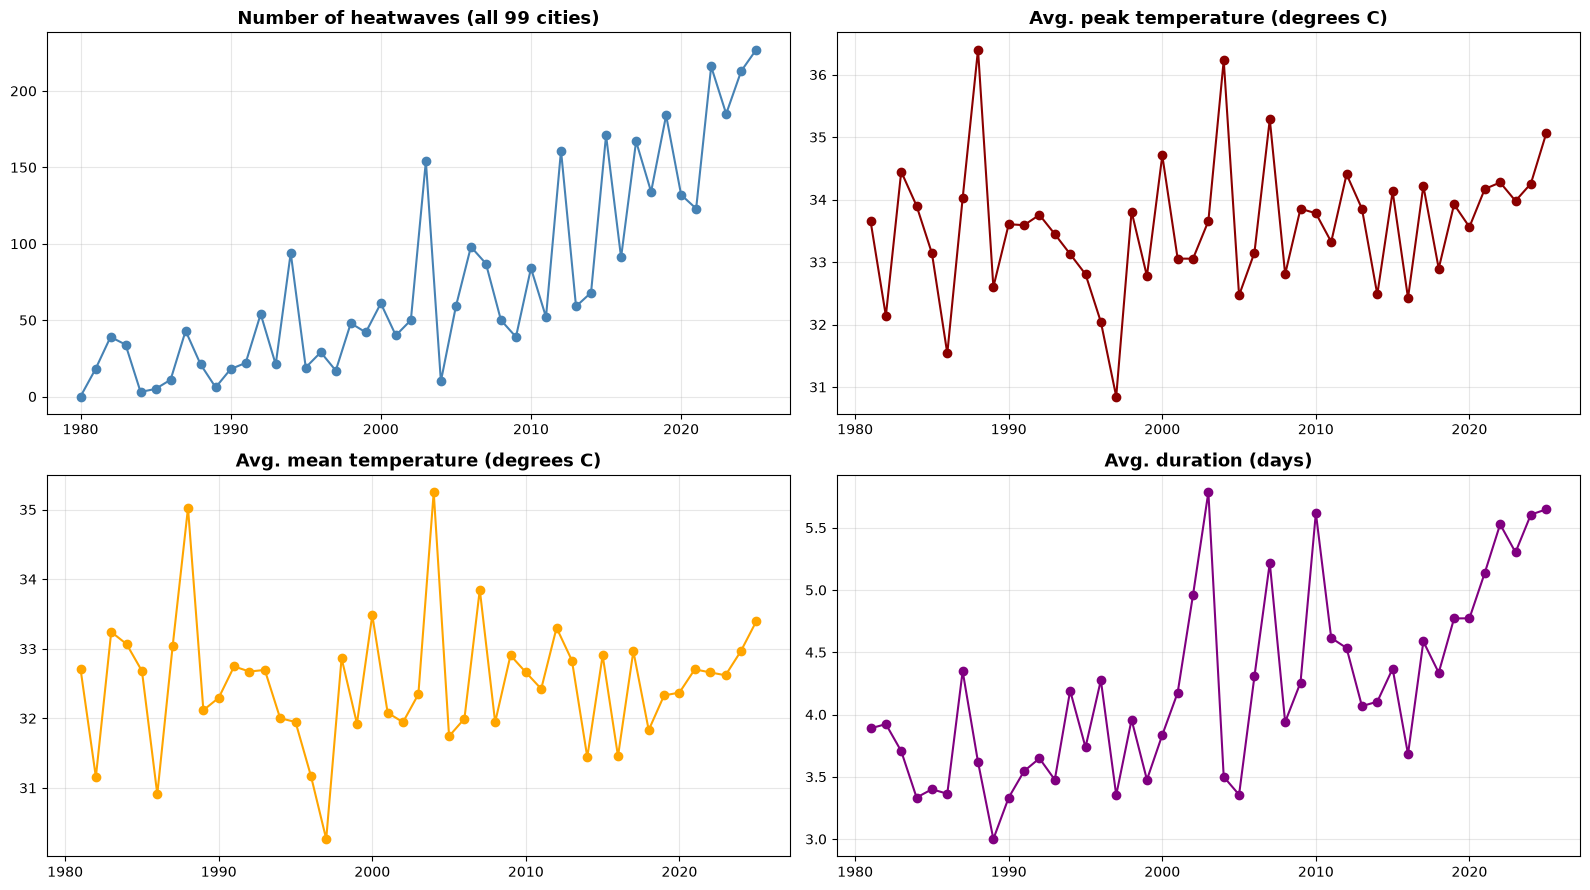

In [8]:
import matplotlib.pyplot as plt

n_cities = len(cities_df) - len(exclude_idx)

yearly = (pd.DataFrame({"year": range(1980, 2026)})
          .merge(results_df.groupby("year").agg(
              n_heatwaves=("city", "count"),
              avg_max_temp=("max_temp", "mean"),
              avg_avg_temp=("avg_temp", "mean"),
              avg_duration=("duration_days", "mean"),
          ).reset_index(), on="year", how="left"))
yearly["n_heatwaves"] = yearly["n_heatwaves"].fillna(0).astype(int)

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
plots = [("n_heatwaves", f"Number of heatwaves (all {n_cities} cities)", axes[0, 0], "steelblue"),
         ("avg_max_temp", "Avg. peak temperature (degrees C)", axes[0, 1], "darkred"),
         ("avg_avg_temp", "Avg. mean temperature (degrees C)", axes[1, 0], "orange"),
         ("avg_duration", "Avg. duration (days)", axes[1, 1], "purple")]

for col, label, ax, color in plots:
    ax.plot(yearly["year"], yearly[col], marker="o", color=color)
    ax.set_title(label, fontsize=13, fontweight="bold")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("data/processed/trend_overview_europe.png", dpi=150)
plt.show()

### Is the trend real?

Linear regression per metric, for the full period and for 1991-2025
(excludes the overlap with the reference period).

In [9]:
from scipy import stats

metrics = [("n_heatwaves", "Frequency"), ("avg_max_temp", "Peak temp."),
           ("avg_avg_temp", "Mean temp."), ("avg_duration", "Duration")]

for period_label, data in [("1980-2025", yearly), ("1991-2025", yearly[yearly["year"] >= 1991])]:
    print(f"-- {period_label} --")
    for col, label in metrics:
        valid = data.dropna(subset=[col])
        slope, _, r, p, _ = stats.linregress(valid["year"], valid[col])
        signif = "significant" if p < 0.05 else "not significant"
        print(f"  {label}: {slope:+.3f}/year, p={p:.4f} ({signif})")

-- 1980-2025 --
  Frequency: +3.995/year, p=0.0000 (significant)
  Peak temp.: +0.016/year, p=0.1854 (not significant)
  Mean temp.: +0.004/year, p=0.6896 (not significant)
  Duration: +0.039/year, p=0.0000 (significant)
-- 1991-2025 --
  Frequency: +5.015/year, p=0.0000 (significant)
  Peak temp.: +0.032/year, p=0.0566 (not significant)
  Mean temp.: +0.015/year, p=0.3058 (not significant)
  Duration: +0.046/year, p=0.0000 (significant)


## 3. Which country is most affected?

Per-city yearly slope of heatwave frequency, then the **median** slope per
country. Robust to city count and outliers, unlike the mean. Countries
with fewer than 3 cities are excluded.

In [10]:
city_trend = []
for city, group in results_df.groupby("city"):
    yearly_city = group.groupby("year").size().reindex(range(1980, 2026), fill_value=0)
    slope, _, _, p, _ = stats.linregress(yearly_city.index, yearly_city.values)
    city_trend.append({"city": city, "country": group["country"].iloc[0], "slope": slope, "p_value": p})

city_trend_df = pd.DataFrame(city_trend)

country_trend = (city_trend_df.groupby("country")
                  .agg(median_slope=("slope", "median"), n_cities=("city", "count"))
                  .query("n_cities >= 3")
                  .sort_values("median_slope", ascending=False))

top3 = country_trend.head(3).index.tolist()
print(country_trend)
print(f"\nTop 3: {top3}")

                median_slope  n_cities
country                               
Italy               0.068239         6
Ukraine             0.065865         9
Spain               0.060870         6
Poland              0.044712         5
France              0.041505         4
Germany             0.037064        15
United Kingdom      0.004810         5

Top 3: ['Italy', 'Ukraine', 'Spain']


**In short:** the country whose cities show the biggest median
yearly increase counts as most affected. Which is Italy, by a clear margin.

### Duration and temperature

Same method, as a cross-check. Cities with fewer than 10 years containing
a heatwave are skipped (too few points for a reliable regression).

In [11]:
city_dt = []
for city, group in results_df.groupby("city"):
    yearly_city = group.groupby("year").agg(avg_duration=("duration_days", "mean"),
                                              avg_temp=("avg_temp", "mean")).reindex(range(1980, 2026))
    row = {"city": city, "country": group["country"].iloc[0]}
    for col, label in [("avg_duration", "duration_slope"), ("avg_temp", "temp_slope")]:
        valid = yearly_city.dropna(subset=[col])
        row[label] = stats.linregress(valid.index, valid[col])[0] if len(valid) >= 10 else np.nan
    city_dt.append(row)

country_dt = pd.DataFrame(city_dt).groupby("country").agg(
    duration_slope=("duration_slope", "median"), temp_slope=("temp_slope", "median"),
    n_cities_duration=("duration_slope", "count"), n_cities_temp=("temp_slope", "count"))

comparison = country_trend.join(country_dt)
print(comparison.sort_values("median_slope", ascending=False))

                median_slope  n_cities  duration_slope  temp_slope  \
country                                                              
Italy               0.068239         6        0.052048    0.015644   
Ukraine             0.065865         9       -0.007232    0.015019   
Spain               0.060870         6        0.019569    0.009840   
Poland              0.044712         5       -0.007060   -0.003568   
France              0.041505         4        0.022577    0.013112   
Germany             0.037064        15        0.020322    0.016241   
United Kingdom      0.004810         5        0.013524    0.035813   

                n_cities_duration  n_cities_temp  
country                                           
Italy                           6              6  
Ukraine                         9              9  
Spain                           6              6  
Poland                          5              5  
France                          4              4  
Germany     

### All three factors compared

Same country order (by frequency trend), top-3 highlighted. Hatched bars
rest on fewer than 3 underlying cities.

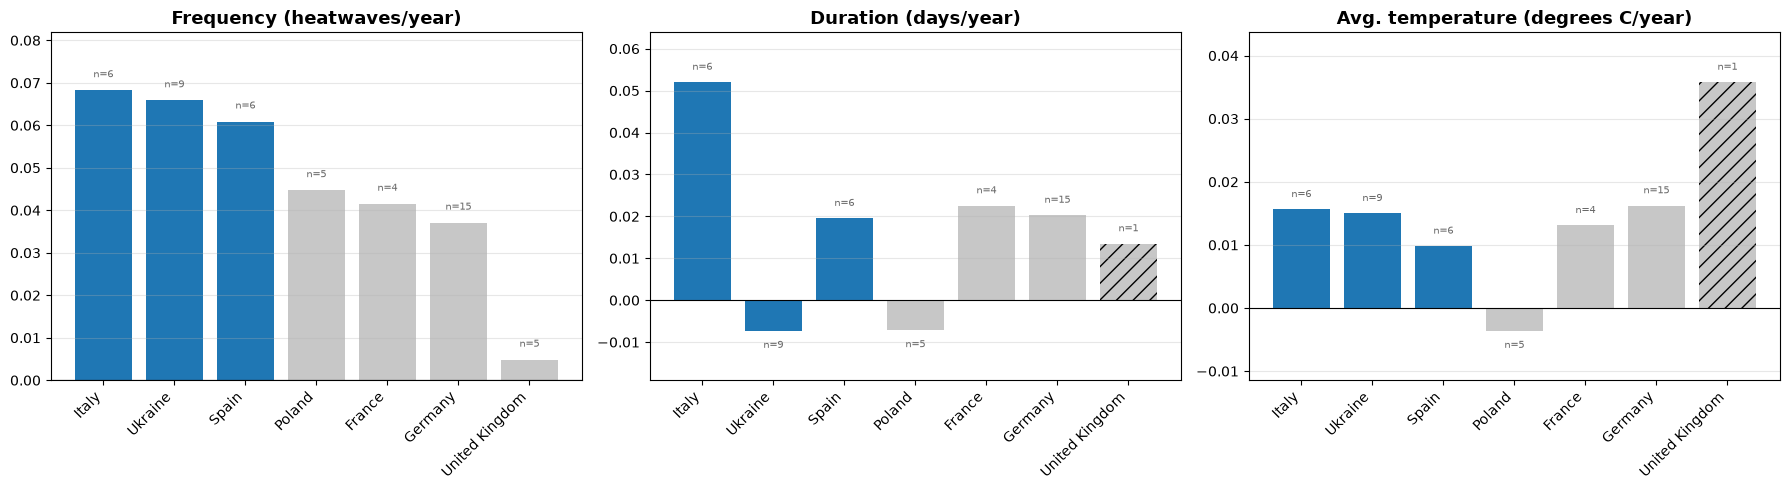

In [12]:
order = comparison.sort_values("median_slope", ascending=False).index.tolist()
factors = [("median_slope", "n_cities", "Frequency (heatwaves/year)"),
           ("duration_slope", "n_cities_duration", "Duration (days/year)"),
           ("temp_slope", "n_cities_temp", "Avg. temperature (degrees C/year)")]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (val_col, n_col, title) in zip(axes, factors):
    values, n_counts = comparison.loc[order, val_col], comparison.loc[order, n_col]
    colors = ["#1f77b4" if c in top3 else "#c7c7c7" for c in order]
    bars = ax.bar(order, values, color=colors)

    ax.margins(y=0.2)  # headroom for the n= labels
    offset = (values.max() - values.min()) * 0.04  # scaled per panel, since each has a different range

    for bar, n in zip(bars, n_counts):
        if n < 3:
            bar.set_hatch("//")
        is_positive = bar.get_height() >= 0
        va = "bottom" if is_positive else "top"
        y = bar.get_height() + offset if is_positive else bar.get_height() - offset
        ax.text(bar.get_x() + bar.get_width() / 2, y, f"n={n}",
                 ha="center", va=va, fontsize=7, color="dimgray")

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order, rotation=45, ha="right")
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("data/processed/trend_by_factor_countries.png", dpi=400)
plt.show()

### Time course, top 3 countries

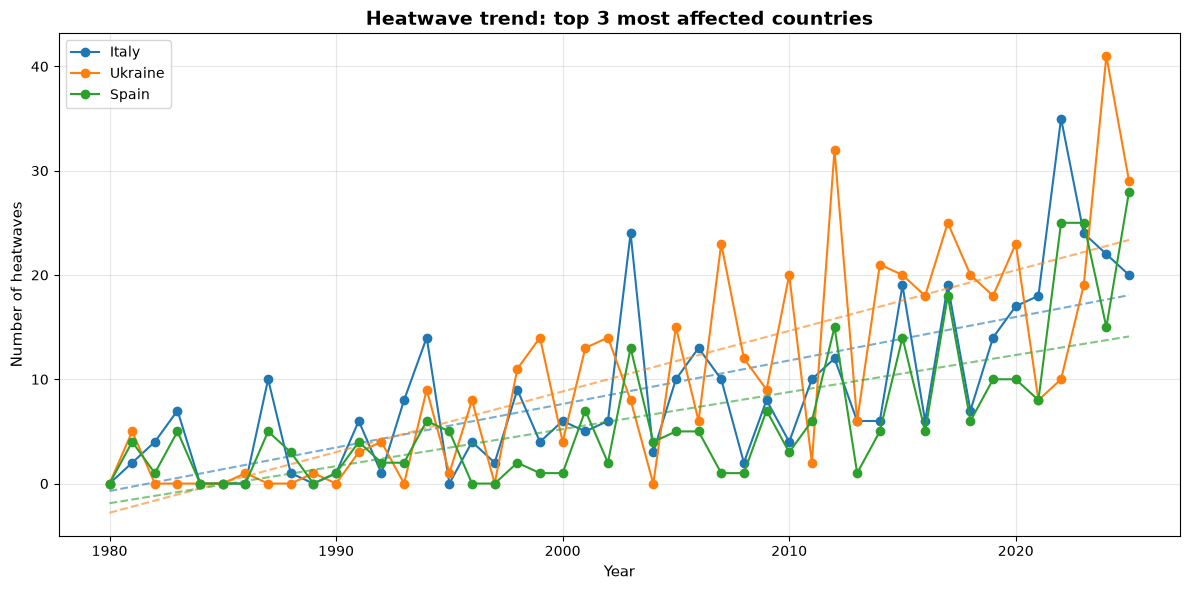

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))
for country in top3:
    country_yearly = (pd.DataFrame({"year": range(1980, 2026)})
                       .merge(results_df[results_df["country"] == country]
                              .groupby("year").size().rename("n").reset_index(),
                              on="year", how="left").fillna({"n": 0}))
    line = ax.plot(country_yearly["year"], country_yearly["n"], marker="o", label=country)[0]
    slope, intercept, *_ = stats.linregress(country_yearly["year"], country_yearly["n"])
    ax.plot(country_yearly["year"], slope * country_yearly["year"] + intercept,
            linestyle="--", alpha=0.6, color=line.get_color())

ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Number of heatwaves", fontsize=11)
ax.set_title("Heatwave trend: top 3 most affected countries", fontsize=14, fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("data/processed/trend_top3_countries.png", dpi=400)
plt.show()

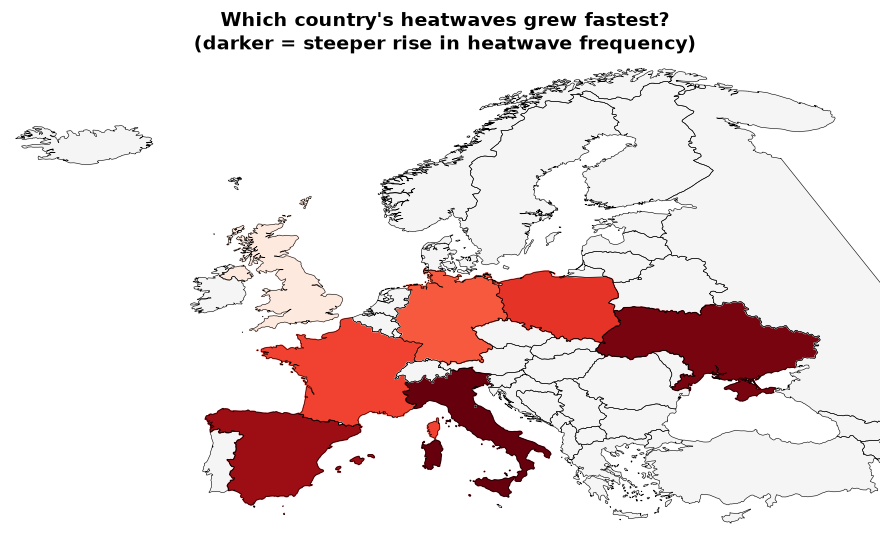

In [15]:
# Mostly AI-generated, used only for visualization
# Choropleth: which country's heatwaves grew fastest?
import matplotlib.cm as cm

cmap = cm.Reds
vmin, vmax = 0, country_trend["median_slope"].max()

fig, ax = plt.subplots(figsize=(9, 9))
for feature in europe_outline["features"]:
    name = feature["properties"]["NAME"]
    geom = feature["geometry"]
    polygons = geom["coordinates"] if geom["type"] == "MultiPolygon" else [geom["coordinates"]]
    if name in country_trend.index:
        val = country_trend.loc[name, "median_slope"]
        color = cmap((val - vmin) / (vmax - vmin))
    else:
        color = "whitesmoke"  # not in country_trend (e.g. <3 cities, or outside the selection)
    for polygon in polygons:
        for ring in polygon:
            ring = np.array(ring)
            ax.plot(ring[:, 0], ring[:, 1], color="black", linewidth=0.4)
            ax.fill(ring[:, 0], ring[:, 1], color=color, zorder=0)

ax.set_title("Which country's heatwaves grew fastest?\n(darker = steeper rise in heatwave frequency)",
              fontsize=14, fontweight="bold")
ax.set_xlim(-25, 45)
ax.set_ylim(34, 72)
ax.set_aspect("equal")
ax.axis("off")
plt.tight_layout()
plt.savefig("data/processed/poster_F_choropleth_countries.png", dpi=400, bbox_inches="tight", facecolor="white")
plt.show()